#Importing Libraries

In [23]:
from pyspark.sql import SparkSession
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.classification import GBTClassifier

from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from sklearn.metrics import classification_report
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
from pyspark.ml.classification import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from pyspark.ml.tuning import CrossValidator
from pyspark.ml.evaluation import BinaryClassificationEvaluator
import time
from sklearn.metrics import ConfusionMatrixDisplay
from pyspark.ml.classification import LinearSVC

#Creation of the Spark Session

In [2]:
spark = SparkSession.builder \
    .appName("Task3_Machine Learning Model Portfolio") \
    .getOrCreate()

#Loading the Dataset

In [3]:
df = spark.read.csv(
    "/content/DelayData.csv",
    header=True,
    inferSchema=True
)

#Printing schema

In [4]:
df.printSchema()



root
 |-- depdelay: integer (nullable = true)
 |-- arrdelay: double (nullable = true)
 |-- scheduleddepartdatetime: string (nullable = true)
 |-- origin: string (nullable = true)
 |-- dest: string (nullable = true)
 |-- uniquecarrier: string (nullable = true)
 |-- marketshareorigin: double (nullable = true)
 |-- marketsharedest: double (nullable = true)
 |-- hhiorigin: double (nullable = true)
 |-- hhidest: double (nullable = true)
 |-- nonhubairportorigin: integer (nullable = true)
 |-- smallhubairportorigin: integer (nullable = true)
 |-- mediumhubairportorigin: integer (nullable = true)
 |-- largehubairportorigin: integer (nullable = true)
 |-- nonhubairportdest: integer (nullable = true)
 |-- smallhubairportdest: integer (nullable = true)
 |-- mediumhubairportdest: integer (nullable = true)
 |-- largehubairportdest: integer (nullable = true)
 |-- nonhubairlineorigin: integer (nullable = true)
 |-- smallhubairlineorigin: integer (nullable = true)
 |-- mediumhubairlineorigin: integer

#Preview of the dataset

In [5]:
df.show(5)

+--------+--------+-----------------------+------+----+-------------+-----------------+---------------+----------+----------+-------------------+---------------------+----------------------+---------------------+-----------------+-------------------+--------------------+-------------------+-------------------+---------------------+----------------------+---------------------+-----------------+-------------------+--------------------+-------------------+----+-----+----------+---------+-------------+---------------+-------------+-------+--------+----------+----------+--------------------+-----------+--------+-------------+-----------------+---------------+----------+---------+----------+----------+----------+-------------+----------------+----------------+-------------+-------------+---------+--------------+---------+--------------+--------------+-----------------------+------------+---------------------+
|depdelay|arrdelay|scheduleddepartdatetime|origin|dest|uniquecarrier|marketshareori

In [6]:

# Creation of Target Variable

from pyspark.sql.functions import when, col

df = df.withColumn(
    "delay_label",
    when(col("arrdelay") > 15, 1).otherwise(0)
)

# Removal of Null Values

feature_columns = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

df = df.na.drop(subset=feature_columns)

# Assemble Features

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="assembled_features",
    handleInvalid="skip"
)

assembled_df = assembler.transform(df)

# Scale Features

scaler = StandardScaler(
    inputCol="assembled_features",
    outputCol="features",
    withMean=True,
    withStd=True
)

scaler_model = scaler.fit(assembled_df)

processed_df = scaler_model.transform(assembled_df)



processed_df.select(
    "features",
    "delay_label"
).show(5, False)

+-------------------------------------------------------------------------------------------------------------------------+-----------+
|features                                                                                                                 |delay_label|
+-------------------------------------------------------------------------------------------------------------------------+-----------+
|[-0.46220878110047664,-0.14750794262808378,0.28655184189123833,-2.114284594583809,-2.628932544100591,0.4200602443243241] |0          |
|[-0.5911721757930601,-0.51108600128472,0.9165497496998161,-2.114284594583809,-1.2740856293935825,0.2047395997622553]     |0          |
|[1.1634565463623714,-0.44302230221427086,0.8906578125210617,0.3274152826984514,-2.669227327946883,-0.22590168936188226]  |0          |
|[2.99800624551039,-0.7477904665559676,-1.6408674998201342,0.44950027656256436,-1.9940749897934698,0.4200602443243241]    |1          |
|[-0.5966213333152819,-2.6856110222432505,-0.206

#Train-test Split

In [7]:
train_df, test_df = processed_df.randomSplit(
    [0.8, 0.2],
    seed=42
)

print("Training Rows:", train_df.count())
print("Testing Rows:", test_df.count())

Training Rows: 568948
Testing Rows: 142415


#Evaluation Function

In [8]:


accuracy_evaluator = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="accuracy"
)

#Logistic Regression Model

In [9]:


# Creation of Logistic Regression Model

lr = LogisticRegression(
    featuresCol="features",
    labelCol="delay_label",
    maxIter=20
)

# Training Model

lr_model = lr.fit(train_df)

# Generating the Predictions

lr_predictions = lr_model.transform(test_df)

# View of the Predictions

lr_predictions.select(
    "delay_label",
    "prediction",
    "probability"
).show(50, False)

+-----------+----------+----------------------------------------+
|delay_label|prediction|probability                             |
+-----------+----------+----------------------------------------+
|0          |0.0       |[0.8841381685807846,0.11586183141921536]|
|0          |0.0       |[0.8655008932194841,0.1344991067805159] |
|0          |0.0       |[0.8905258794482586,0.10947412055174144]|
|0          |0.0       |[0.7583785358647631,0.24162146413523689]|
|0          |0.0       |[0.7246767499344211,0.2753232500655789] |
|0          |0.0       |[0.7975136007480036,0.2024863992519964] |
|0          |0.0       |[0.8306491685867584,0.1693508314132416] |
|0          |0.0       |[0.7167763927694535,0.2832236072305465] |
|0          |0.0       |[0.6315641520284628,0.36843584797153717]|
|0          |0.0       |[0.8922108416667165,0.10778915833328351]|
|0          |0.0       |[0.8245795244720527,0.17542047552794726]|
|0          |0.0       |[0.7052228019941481,0.2947771980058519] |
|0        

***Classification Report***

In [10]:


# Accuracy

accuracy = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(lr_predictions)

# Precision

precision = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(lr_predictions)

# Recall

recall = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(lr_predictions)

# F1 Score

f1 = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(lr_predictions)

# ROC AUC

auc = BinaryClassificationEvaluator(
    labelCol="delay_label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(lr_predictions)

# Classification Report


print("LOGISTIC REGRESSION CLASSIFICATION REPORT")

print(f"Accuracy            : {accuracy:.4f}")
print(f"Weighted Precision  : {precision:.4f}")
print(f"Weighted Recall     : {recall:.4f}")
print(f"F1 Score            : {f1:.4f}")
print(f"ROC-AUC             : {auc:.4f}")


LOGISTIC REGRESSION CLASSIFICATION REPORT
Accuracy            : 0.8068
Weighted Precision  : 0.7153
Weighted Recall     : 0.8068
F1 Score            : 0.7205
ROC-AUC             : 0.6237


#Confusion Matrix

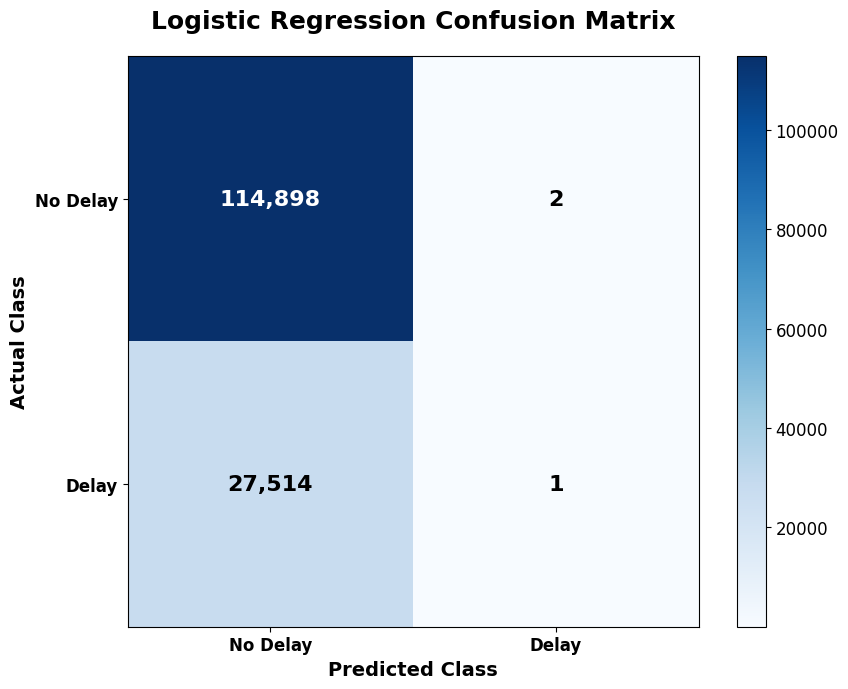

In [50]:


# Extraction of actual and predicted values

y_true = [row["delay_label"] for row in lr_predictions.select("delay_label").collect()]
y_pred = [row["prediction"] for row in lr_predictions.select("prediction").collect()]

# Creation of Confusion Matrix

cm = confusion_matrix(y_true, y_pred)

# Visualization

fig, ax = plt.subplots(figsize=(9,7))

im = ax.imshow(cm, cmap="Blues")

# Labels

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, fontsize=12, fontweight='bold')
ax.set_yticklabels(classes, fontsize=12, fontweight='bold')

ax.set_xlabel("Predicted Class", fontsize=14, fontweight='bold')
ax.set_ylabel("Actual Class", fontsize=14, fontweight='bold')

ax.set_title(
    "Logistic Regression Confusion Matrix",
    fontsize=18,
    fontweight='bold',
    pad=20
)

# Addition of Values

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i, j]:,}",
            ha="center",
            va="center",
            fontsize=16,
            fontweight="bold",
            color="white" if cm[i, j] > cm.max()/2 else "black"
        )



cbar = plt.colorbar(im)
cbar.ax.tick_params(labelsize=12)

plt.tight_layout()
plt.show()

#Decison Tree


In [12]:


dt = DecisionTreeClassifier(
    labelCol="delay_label",
    featuresCol="features",
    maxDepth=10
)

dt_model = dt.fit(train_df)

dt_predictions = dt_model.transform(test_df)

dt_predictions.select(
    "delay_label",
    "prediction",
    "probability"
).show(10, False)

+-----------+----------+----------------------------------------+
|delay_label|prediction|probability                             |
+-----------+----------+----------------------------------------+
|0          |0.0       |[0.9122729286663713,0.08772707133362871]|
|0          |0.0       |[0.8599348534201955,0.14006514657980457]|
|0          |0.0       |[0.8355555555555556,0.16444444444444445]|
|0          |0.0       |[0.769690461739577,0.230309538260423]   |
|0          |0.0       |[0.769690461739577,0.230309538260423]   |
|0          |0.0       |[0.8390074636637423,0.16099253633625768]|
|0          |0.0       |[0.8390074636637423,0.16099253633625768]|
|0          |0.0       |[0.7077813308969088,0.2922186691030912] |
|0          |0.0       |[0.5573248407643312,0.4426751592356688] |
|0          |0.0       |[0.9122729286663713,0.08772707133362871]|
+-----------+----------+----------------------------------------+
only showing top 10 rows


***Classification Report***

In [13]:


accuracy = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(dt_predictions)

precision = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(dt_predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(dt_predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(dt_predictions)

auc = BinaryClassificationEvaluator(
    labelCol="delay_label",
    rawPredictionCol="rawPrediction",
    metricName="areaUnderROC"
).evaluate(dt_predictions)


print("DECISION TREE CLASSIFICATION REPORT")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")


DECISION TREE CLASSIFICATION REPORT
Accuracy  : 0.8055
Precision : 0.7222
Recall    : 0.8055
F1 Score  : 0.7231
ROC-AUC   : 0.5196


***Confusion Matrix***

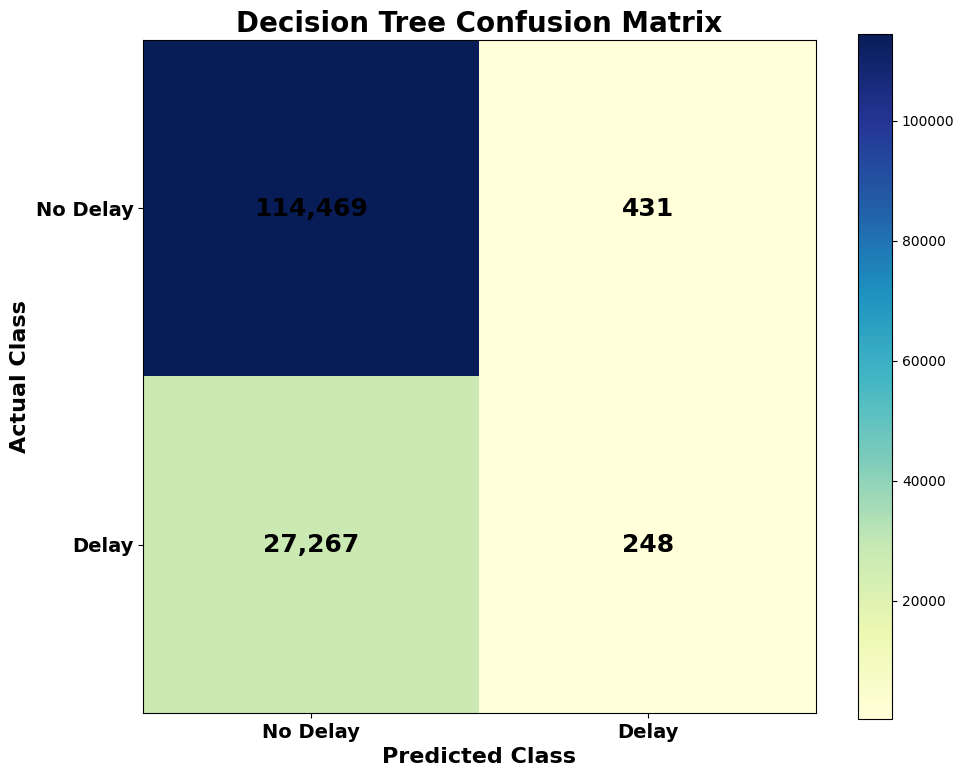

In [14]:


y_true = [
    row["delay_label"]
    for row in dt_predictions.select("delay_label").collect()
]

y_pred = [
    row["prediction"]
    for row in dt_predictions.select("prediction").collect()
]

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(cm, cmap="YlGnBu")

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(len(classes)))
ax.set_yticks(np.arange(len(classes)))

ax.set_xticklabels(classes, fontsize=14, fontweight='bold')
ax.set_yticklabels(classes, fontsize=14, fontweight='bold')

ax.set_xlabel("Predicted Class", fontsize=16, fontweight='bold')
ax.set_ylabel("Actual Class", fontsize=16, fontweight='bold')

ax.set_title(
    "Decision Tree Confusion Matrix",
    fontsize=20,
    fontweight='bold'
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i,j]:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

***Feature Importance Plot***

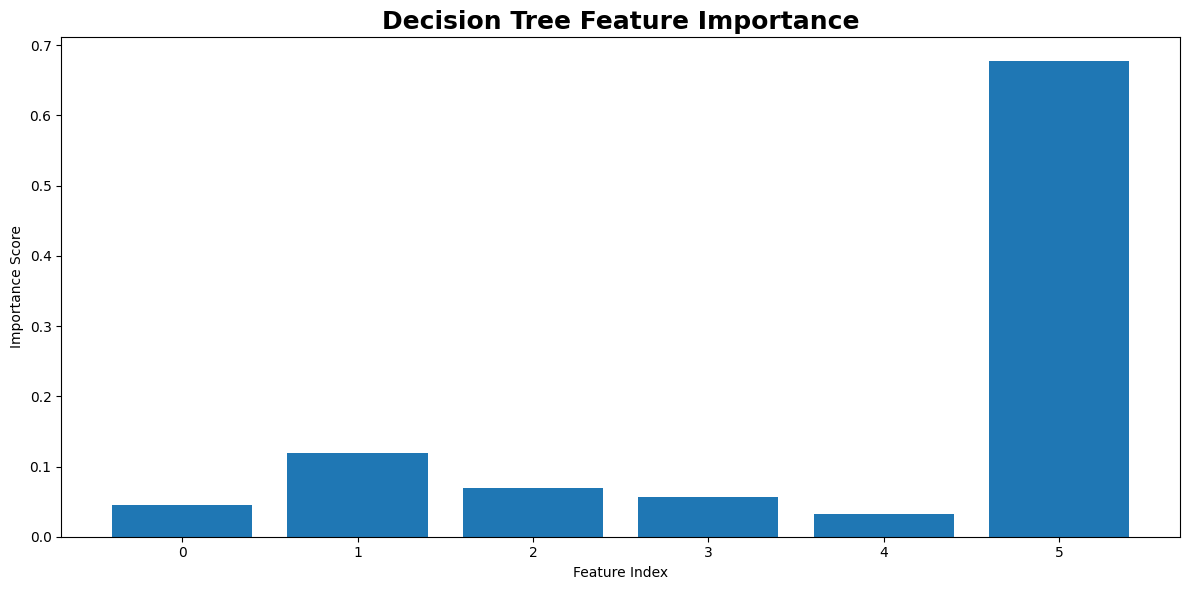

In [15]:
importance = dt_model.featureImportances.toArray()

plt.figure(figsize=(12,6))

plt.bar(
    range(len(importance)),
    importance
)

plt.title(
    "Decision Tree Feature Importance",
    fontsize=18,
    fontweight='bold'
)

plt.xlabel("Feature Index")
plt.ylabel("Importance Score")

plt.tight_layout()
plt.show()

***K-N-N Classifier***

In [16]:
X_train = np.array(train_df.select("features").rdd.map(lambda x: x[0].toArray()).collect())
y_train = np.array(train_df.select("delay_label").rdd.flatMap(lambda x: x).collect())

X_test = np.array(test_df.select("features").rdd.map(lambda x: x[0].toArray()).collect())
y_test = np.array(test_df.select("delay_label").rdd.flatMap(lambda x: x).collect())

In [18]:


knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

***Classification Report***

In [20]:


print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.94      0.87    114900
           1       0.27      0.09      0.14     27515

    accuracy                           0.77    142415
   macro avg       0.54      0.52      0.50    142415
weighted avg       0.71      0.77      0.73    142415



***Confusion Matrix***

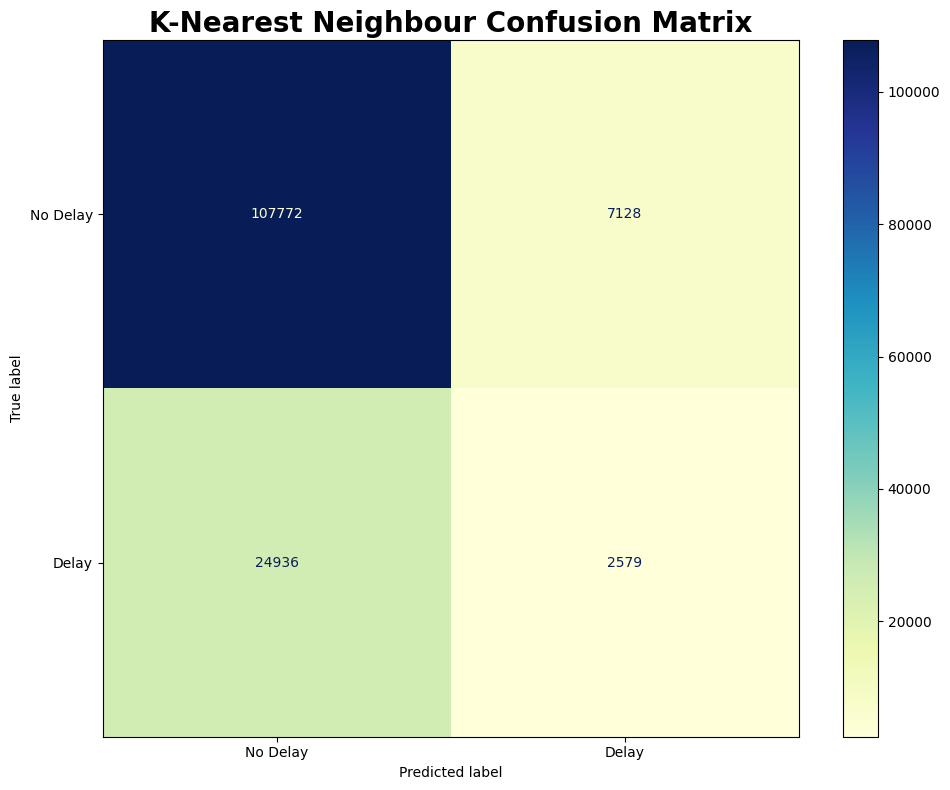

In [21]:


cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Delay", "Delay"]
)

disp.plot(
    ax=ax,
    cmap="YlGnBu",
    colorbar=True
)

plt.title(
    "K-Nearest Neighbour Confusion Matrix",
    fontsize=20,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

#Support Vector Machine

In [26]:


svm = LinearSVC(
    featuresCol="features",
    labelCol="delay_label",
    maxIter=20,
    regParam=0.1
)

svm_model = svm.fit(train_df)

svm_predictions = svm_model.transform(test_df)

svm_predictions.select(
    "delay_label",
    "prediction"
).show(10, False)

+-----------+----------+
|delay_label|prediction|
+-----------+----------+
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
|0          |0.0       |
+-----------+----------+
only showing top 10 rows


***Classification Report***

In [27]:


accuracy = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="accuracy"
).evaluate(svm_predictions)

precision = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="weightedPrecision"
).evaluate(svm_predictions)

recall = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="weightedRecall"
).evaluate(svm_predictions)

f1 = MulticlassClassificationEvaluator(
    labelCol="delay_label",
    predictionCol="prediction",
    metricName="f1"
).evaluate(svm_predictions)


print("SUPPORT VECTOR MACHINE CLASSIFICATION REPORT")
print("="*50)
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")


SUPPORT VECTOR MACHINE CLASSIFICATION REPORT
Accuracy  : 0.8068
Precision : 0.6509
Recall    : 0.8068
F1 Score  : 0.7205


***Confusion Matrix***

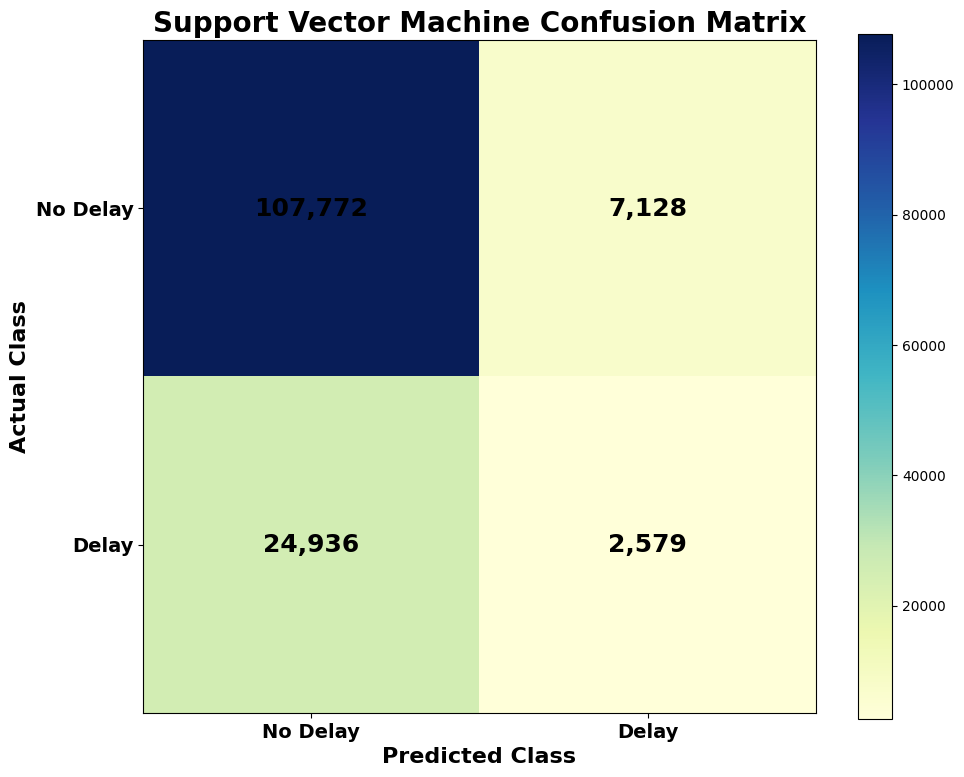

In [28]:


cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(10,8))

im = ax.imshow(cm, cmap="YlGnBu")

classes = ["No Delay", "Delay"]

ax.set_xticks(np.arange(2))
ax.set_yticks(np.arange(2))

ax.set_xticklabels(classes, fontsize=14, fontweight="bold")
ax.set_yticklabels(classes, fontsize=14, fontweight="bold")

ax.set_xlabel(
    "Predicted Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Actual Class",
    fontsize=16,
    fontweight="bold"
)

ax.set_title(
    "Support Vector Machine Confusion Matrix",
    fontsize=20,
    fontweight="bold"
)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j,
            i,
            f"{cm[i,j]:,}",
            ha="center",
            va="center",
            fontsize=18,
            fontweight="bold",
            color="black"
        )

plt.colorbar(im)
plt.tight_layout()
plt.show()

***Feature Importance Plot***


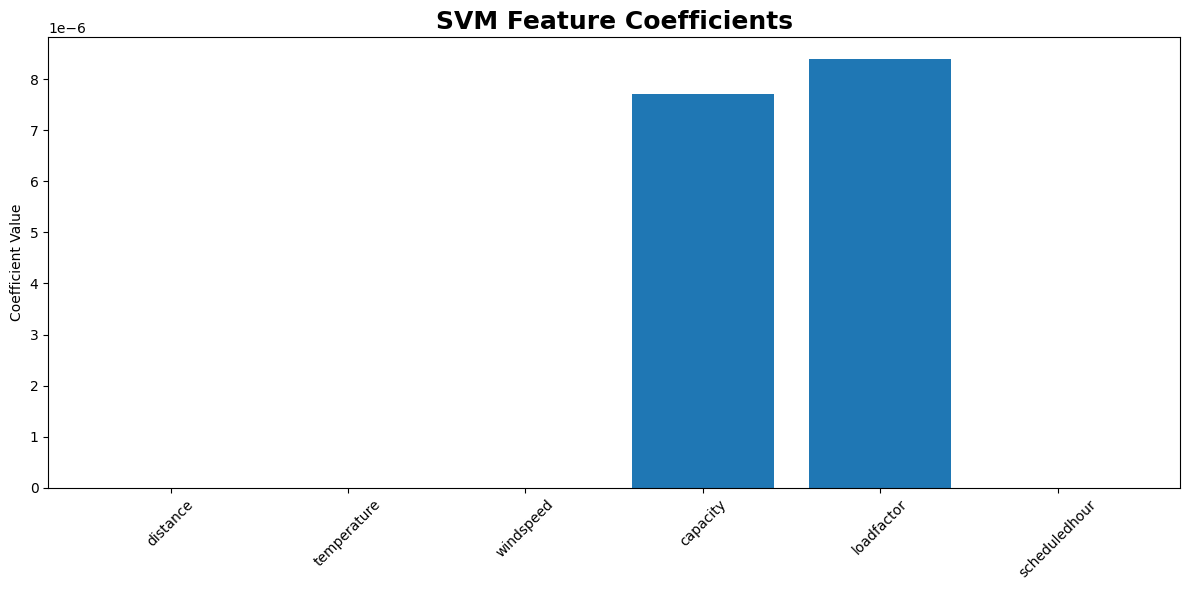

In [29]:
feature_names = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

coefficients = svm_model.coefficients.toArray()

plt.figure(figsize=(12,6))

plt.bar(
    feature_names,
    coefficients
)

plt.title(
    "SVM Feature Coefficients",
    fontsize=18,
    fontweight="bold"
)

plt.ylabel("Coefficient Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Hyperparameter tuning using CrossValidator

***Random Forest***

In [30]:

rf = RandomForestClassifier(
    labelCol="delay_label",
    featuresCol="features",
    seed=42
)

***Creation of parameter Grid***

In [31]:
from pyspark.ml.tuning import ParamGridBuilder

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [3, 5]) \
    .build()
print("Total Parameter Combinations:", len(paramGrid))

Total Parameter Combinations: 4


***Cross-validation***

In [32]:
crossval = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=BinaryClassificationEvaluator(
        labelCol="delay_label"
    ),
    numFolds=2
)

***Running the Hyperparameter Tuning***

In [33]:
start_time = time.time()

cv_model = crossval.fit(train_df)

end_time = time.time()

print(
    "Training Time:",
    round(end_time - start_time, 2),
    "seconds"
)

Training Time: 268.96 seconds


***Showing All Parameter Scores***


In [34]:
best_model = cv_model.bestModel

print("Best Number of Trees:")
print(best_model.getNumTrees)

print("\nBest Maximum Depth:")
print(best_model.getOrDefault("maxDepth"))

Best Number of Trees:
20

Best Maximum Depth:
5


***Generating the Tuned Predictions***

In [36]:
cv_predictions = cv_model.bestModel.transform(test_df)

cv_predictions.select(
    "delay_label",
    "prediction",
    "probability"
).show(70, False)


+-----------+----------+----------------------------------------+
|delay_label|prediction|probability                             |
+-----------+----------+----------------------------------------+
|0          |0.0       |[0.8201004159572791,0.17989958404272077]|
|0          |0.0       |[0.8204524898978466,0.17954751010215347]|
|0          |0.0       |[0.8177200512857017,0.18227994871429828]|
|0          |0.0       |[0.7959208523083046,0.2040791476916955] |
|0          |0.0       |[0.7959208523083046,0.2040791476916955] |
|0          |0.0       |[0.8177200512857017,0.18227994871429828]|
|0          |0.0       |[0.8177200512857017,0.18227994871429828]|
|0          |0.0       |[0.7959208523083046,0.2040791476916955] |
|0          |0.0       |[0.7830989002831068,0.2169010997168932] |
|0          |0.0       |[0.8201004159572791,0.17989958404272077]|
|0          |0.0       |[0.8177200512857017,0.18227994871429828]|
|0          |0.0       |[0.7959208523083046,0.2040791476916955] |
|0        

#Training Time

***Logistic Regression***

In [38]:
start_time = time.time()

lr_model = lr.fit(train_df)

end_time = time.time()


print("LOGISTIC REGRESSION TRAINING TIME")
print("Training Time:", round(end_time - start_time, 2), "seconds")

LOGISTIC REGRESSION TRAINING TIME
Training Time: 46.3 seconds


***Decision-Tree***

In [41]:
start_time = time.time()

dt_model = dt.fit(train_df)

end_time = time.time()


print("DECISION TREE TRAINING TIME")

print("Training Time:", round(end_time - start_time, 2), "seconds")

DECISION TREE TRAINING TIME
Training Time: 101.99 seconds


***Random Forest***

In [42]:
start_time = time.time()

rf_model = rf.fit(train_df)

end_time = time.time()


print("RANDOM FOREST TRAINING TIME")
print("Training Time:", round(end_time - start_time, 2), "seconds")

RANDOM FOREST TRAINING TIME
Training Time: 80.93 seconds


***SVM***

In [43]:
start_time = time.time()

svm_model = svm.fit(train_df)

end_time = time.time()


print("SVM TRAINING TIME")

print("Training Time:", round(end_time - start_time, 2), "seconds")

SVM TRAINING TIME
Training Time: 50.21 seconds


***KNN***


In [44]:

# Training KNN

knn = KNeighborsClassifier(
    n_neighbors=5
)

knn.fit(X_train, y_train)

# End Timer

end_time = time.time()

# Training Time

training_time = end_time - start_time


print("KNN TRAINING TIME")

print("Training Time:", round(training_time, 4), "seconds")


KNN TRAINING TIME
Training Time: 52.3879 seconds


#Prediction Time

In [45]:
start_time = time.time()

y_pred = knn.predict(X_test)

end_time = time.time()

prediction_time = end_time - start_time


print("KNN PREDICTION TIME")

print("Prediction Time:", round(prediction_time, 4), "seconds")


KNN PREDICTION TIME
Prediction Time: 15.9803 seconds


#Model Summary

***Logistic Regression Model Summary***

In [46]:

print("LOGISTIC REGRESSION MODEL SUMMARY")


print("Intercept:")
print(lr_model.intercept)

print("\nCoefficients:")
print(lr_model.coefficients)

print("\nNumber of Features:")
print(len(lr_model.coefficients))

LOGISTIC REGRESSION MODEL SUMMARY
Intercept:
-1.4877105576860847

Coefficients:
[0.03200897139729149,-0.08654017370486819,0.14224228741425674,-0.04239358191626248,0.06828808484512165,0.4045014151012535]

Number of Features:
6


***Decision Tree Model Summary***

In [47]:

print("DECISION TREE MODEL SUMMARY")

print(dt_model.toDebugString)

DECISION TREE MODEL SUMMARY
DecisionTreeClassificationModel: uid=DecisionTreeClassifier_6a79b0b9bdb9, depth=10, numNodes=809, numClasses=2, numFeatures=6
  If (feature 5 <= -0.11824136708084787)
   If (feature 5 <= -0.9795239453291231)
    If (feature 1 <= -1.4103938946974097)
     If (feature 2 <= 0.1711181513455352)
      If (feature 3 <= -0.06302163296984134)
       If (feature 0 <= -0.42678925720603467)
        If (feature 5 <= -1.4101652344532607)
         If (feature 4 <= 0.1818516928342509)
          Predict: 0.0
         Else (feature 4 > 0.1818516928342509)
          If (feature 4 <= 1.4590037639794051)
           Predict: 0.0
          Else (feature 4 > 1.4590037639794051)
           If (feature 0 <= -1.067973458987471)
            Predict: 0.0
           Else (feature 0 > -1.067973458987471)
            Predict: 1.0
        Else (feature 5 > -1.4101652344532607)
         Predict: 0.0
       Else (feature 0 > -0.42678925720603467)
        If (feature 1 <= -1.6135214168586036)

***SVM Model Summary***

In [48]:
print("SVM MODEL SUMMARY")


print("Intercept:")
print(svm_model.intercept)

print("\nCoefficients:")
print(svm_model.coefficients)

SVM MODEL SUMMARY
Intercept:
-1.0000170009350173

Coefficients:
[0.0,0.0,-0.0,7.698839066334182e-06,8.395872373221577e-06,-0.0]


***Feature Importance Summary***

In [49]:
feature_names = [
    "distance",
    "temperature",
    "windspeed",
    "capacity",
    "loadfactor",
    "scheduledhour"
]

importance = rf_model.featureImportances.toArray()

for feature, score in zip(feature_names, importance):
    print(f"{feature}: {score:.4f}")

distance: 0.0003
temperature: 0.1302
windspeed: 0.0166
capacity: 0.0011
loadfactor: 0.0003
scheduledhour: 0.8515
